# Pauli–Fierz QED-TDDFT (TDA) + PES scans — GTO backend

Interactive checks for:

1. **GTO electronic TDA** vs PySCF (`GTOKernel` / `run_casida`)
2. **QED-TDA** assembly (`casidapy.utils.qed`) — DSE, coherent-state shift, photonic fraction
3. **λ-scan** at fixed geometry (Rabi splitting)
4. **PES scan** along H₂ bond length with overlap-tracked polariton branches

Level A ground state: ordinary PySCF RKS/RHF (dipole self-energy in the response only).

## Prerequisites

```bash
pip install pyscf matplotlib
# from the casidapy repo root (or editable install):
pip install -e .
```

This notebook is intentionally small (H₂ / LiH) so cells finish in seconds, not minutes.

In [4]:
%matplotlib inline

import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

from pyscf import gto, dft, scf, tdscf

from casidapy.adapter.pyscf import extract_gto_kernel
from casidapy.casida_engine import run_casida
from casidapy import qed
from casidapy.utils.qed import QEDOptions, solve_qed_tda, scan_qed_tda, build_qed_tda_matrix

HA_TO_EV = 27.211386245988
print("casidapy.utils.qed constants:",
      f"SQRT2={qed.SQRT2:.6f}, DSE_DIRECT_FACTOR={qed.DSE_DIRECT_FACTOR}")

casidapy.utils.qed constants: SQRT2=1.414214, DSE_DIRECT_FACTOR=2.0


## Helpers

Build a converged mean-field + ready `GTOKernel` once per geometry (reuse across QED calls).

In [5]:
def make_mf(atom, basis="6-31g", xc="pbe", charge=0, spin=0):
    """Converge RKS (or RHF if xc='hf')."""
    mol = gto.M(atom=atom, basis=basis, charge=charge, spin=spin, verbose=0)
    if str(xc).lower() in ("hf", "rhf"):
        mf = scf.RHF(mol)
    else:
        mf = dft.RKS(mol)
        mf.xc = xc
    mf.kernel()
    return mf


def make_gto_kernel(mf, *, tda=True, use_df=False, n_states=6, verbose=True):
    """extract_gto_kernel + setup (caches dense K when n_trans is small)."""
    kernel, opts = extract_gto_kernel(
        mf, n_states=n_states, tda=tda, use_df=use_df, verbose=False
    )
    t0 = time.time()
    kernel.setup(tda=tda)
    dt = time.time() - t0
    if verbose:
        print(
            f"  GTOKernel ready: n_occ={kernel.n_occ}, n_unocc={kernel.n_unocc}, "
            f"n_trans={kernel.n_trans}, K_cached={kernel._K is not None} "
            f"({dt:.2f}s)"
        )
    return kernel, opts


def bare_tda_spectrum(kernel):
    """Electronic TDA roots from cached K (no cavity)."""
    A = kernel._K + np.diag(kernel.diagonal_dE())
    w, V = np.linalg.eigh(A)
    mu = kernel.dipole_matrix()
    d = V.T @ mu
    f = (2.0 / 3.0) * w * np.einsum("nx,nx->n", d, d)
    return w, V, f

---
## 1. GTO electronic TDA vs PySCF

Sanity check that the GTO backend matches PySCF TDA before turning on the cavity.

In [6]:
mf_h2 = make_mf("H 0 0 0; H 0 0 0.74", basis="6-31g", xc="pbe")
print(f"H2 E_SCF = {mf_h2.e_tot:.8f} Ha")

kernel_h2, opts_h2 = make_gto_kernel(mf_h2, tda=True, use_df=False, n_states=4)
print(f"n_trans = {kernel_h2.n_trans}  (H₂/6-31g: 1 occ × 3 virt)")

# Full electronic spectrum from cached K (exact dense eigh — best parity check)
w_gto, _, _ = bare_tda_spectrum(kernel_h2)

td = tdscf.TDA(mf_h2)
td.nstates = kernel_h2.n_trans
td.kernel()
w_pyscf = np.asarray(td.e)

print("\n ω / Ha  (dense GTOKernel K vs PySCF TDA)")
print(f"  {'#':>3}  {'GTOKernel':>12}  {'PySCF TDA':>12}  {'Δ':>10}")
n_cmp = min(len(w_gto), len(w_pyscf))
for i in range(n_cmp):
    a, b = w_gto[i], w_pyscf[i]
    print(f"  {i:3d}  {a:12.6f}  {b:12.6f}  {a-b:10.3e}")

assert np.allclose(w_gto[:n_cmp], w_pyscf[:n_cmp], atol=1e-5), \
    "GTO kernel diverges from PySCF TDA"
print("\n✓ GTO TDA (cached K) matches PySCF")

# Optional: matrix-free run_casida / eigsh — must request k < n_trans
opts_h2.solver_method = "eigsh"
opts_h2.n_states = max(1, kernel_h2.n_trans - 1)
res_casida = run_casida(kernel_h2, opts_h2)
assert np.allclose(res_casida.omega, w_pyscf[: len(res_casida.omega)], atol=1e-5)
print(f"✓ run_casida/eigsh matches first {len(res_casida.omega)} PySCF roots "
      f"(eigsh cannot return k == n_trans for a LinearOperator)")

H2 E_SCF = -1.16190441 Ha
  GTOKernel ready: n_occ=1, n_unocc=3, n_trans=3, K_cached=True (17.60s)
n_trans = 3  (H₂/6-31g: 1 occ × 3 virt)

 ω / Ha  (dense GTOKernel K vs PySCF TDA)
    #     GTOKernel     PySCF TDA           Δ
    0      0.551077      0.551077   3.331e-16
    1      1.049647      1.049647   0.000e+00
    2      1.571408      1.571408   0.000e+00

✓ GTO TDA (cached K) matches PySCF
Matrix-free mode initialized:
  Backend: GTOKernel
  Transitions: 1 occ × 3 unocc = 3
  (Full matrix would be: 0.00 GB)
  TDA: True, CPU

Solving TDA using EIGSH
  Matrix size: 3 x 3
  Seeking 2 eigenvalues, tolerance: 1e-08
eigsh solver:
  Matrix size: 3
  Number of roots: 2
  Tolerance: 1e-08
  Max iterations: 200
  Converged eigenvalues: [0.55107657 1.0496473 ]

Excitation energies (eV):
  State 1: 14.9956 eV
  State 2: 28.5624 eV
✓ run_casida/eigsh matches first 2 PySCF roots (eigsh cannot return k == n_trans for a LinearOperator)


---
## 2. QED-TDA at fixed geometry

Tune the cavity near the brightest bare electronic root and compare:

- `λ = 0` → bare TDA ⊕ free photon at `ω_c`
- finite `λ` → polariton splitting, photonic fraction `|m|²`
- DSE on/off diagnostic

In [7]:
w_bare, _, f_bare = bare_tda_spectrum(kernel_h2)
ib = int(np.argmax(np.clip(f_bare, 0, None)))
omega_c = float(w_bare[ib])
print(f"Brightest bare root: state {ib}, ω={omega_c:.6f} Ha "
      f"({omega_c*HA_TO_EV:.3f} eV), f={f_bare[ib]:.4f}")

lam_scalar = 0.04
polarization = (0.0, 0.0, 1.0)  # along bond

r0 = solve_qed_tda(
    kernel_h2, lam_vec=[0, 0, 0], omega_c=omega_c, nstates=None
)
rλ = solve_qed_tda(
    kernel_h2,
    options=QEDOptions(
        lam_scalar=lam_scalar,
        polarization=polarization,
        omega_c=omega_c,
        include_dse=True,
        coherent_state=True,
    ),
)
r_no_dse = solve_qed_tda(
    kernel_h2,
    options=QEDOptions(
        lam_scalar=lam_scalar,
        polarization=polarization,
        omega_c=omega_c,
        include_dse=False,
    ),
)

print(f"\nλ=0: photon root near ω_c? "
      f"{np.min(np.abs(r0.omega - omega_c)) < 1e-10}")
print(f"λ={lam_scalar}: max |m|² = {rλ.photon_frac.max():.4f}")
print(f"DSE on vs off max|Δω| = {np.max(np.abs(rλ.omega - r_no_dse.omega)):.4e} Ha")

# Normalization check
for k in range(min(5, rλ.omega.size)):
    nrm = np.dot(rλ.X[:, k], rλ.X[:, k]) + rλ.m[k] ** 2
    assert abs(nrm - 1.0) < 1e-10
print("✓ eigenvector normalization ‖X‖²+|m|² = 1")

Brightest bare root: state 0, ω=0.551077 Ha (14.996 eV), f=0.3664

λ=0: photon root near ω_c? True
λ=0.04: max |m|² = 0.5274
DSE on vs off max|Δω| = 1.6332e-03 Ha
✓ eigenvector normalization ‖X‖²+|m|² = 1


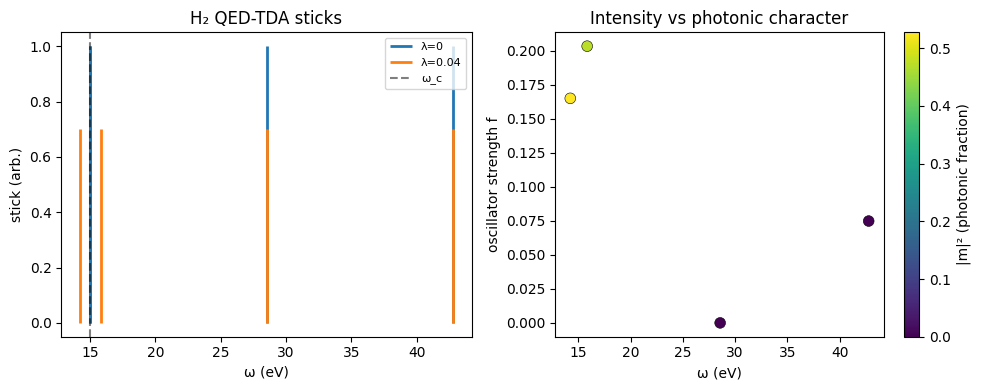

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

ax = axes[0]
nshow = min(8, rλ.omega.size)
ax.vlines(r0.omega[:nshow] * HA_TO_EV, 0, 1.0, colors="C0", label="λ=0", lw=2)
ax.vlines(rλ.omega[:nshow] * HA_TO_EV, 0, 0.7, colors="C1", label=f"λ={lam_scalar}", lw=2)
ax.axvline(omega_c * HA_TO_EV, color="k", ls="--", alpha=0.5, label="ω_c")
ax.set_xlabel("ω (eV)")
ax.set_ylabel("stick (arb.)")
ax.set_title("H₂ QED-TDA sticks")
ax.legend(fontsize=8)

ax = axes[1]
order = np.argsort(rλ.omega)[:nshow]
sc = ax.scatter(
    rλ.omega[order] * HA_TO_EV,
    np.clip(rλ.f[order], 0, None),
    c=rλ.photon_frac[order],
    cmap="viridis",
    s=60,
    edgecolors="k",
    linewidths=0.4,
)
cb = plt.colorbar(sc, ax=ax)
cb.set_label("|m|² (photonic fraction)")
ax.set_xlabel("ω (eV)")
ax.set_ylabel("oscillator strength f")
ax.set_title("Intensity vs photonic character")
fig.tight_layout()
plt.show()

### Origin / coherent-state check (LiH)

Excitation energies must be invariant under a pure gauge-origin shift when DSE + coherent-state are on.

In [9]:
mf_lih = make_mf("Li 0 0 0; H 0 0 1.6", basis="sto-3g", xc="hf")
kernel_lih, _ = make_gto_kernel(mf_lih, use_df=False, n_states=4)

lam = [0.0, 0.0, 0.04]
oc = 0.15
shift = (1.7, -0.9, 2.3)

w_a = solve_qed_tda(kernel_lih, lam, oc, origin=(0, 0, 0), coherent_state=True).omega
w_b = solve_qed_tda(kernel_lih, lam, oc, origin=shift, coherent_state=True).omega
drift_cs = float(np.max(np.abs(w_a - w_b)))

w_c = solve_qed_tda(kernel_lih, lam, oc, origin=(0, 0, 0), coherent_state=False).omega
w_d = solve_qed_tda(kernel_lih, lam, oc, origin=shift, coherent_state=False).omega
drift_raw = float(np.max(np.abs(w_c - w_d)))

print(f"max|Δω| with coherent-state : {drift_cs:.3e} Ha")
print(f"max|Δω| without coherent-state: {drift_raw:.3e} Ha")
assert drift_cs < 1e-8, "origin invariance failed — check CS / N_e shift"
assert drift_raw > 1e-6, "expected origin drift without CS"
print("✓ coherent-state restores gauge-origin invariance")

  GTOKernel ready: n_occ=2, n_unocc=4, n_trans=8, K_cached=True (1.33s)
max|Δω| with coherent-state : 8.882e-16 Ha
max|Δω| without coherent-state: 1.479e-02 Ha
✓ coherent-state restores gauge-origin invariance


---
## 3. Coupling-strength (λ) scan at fixed geometry

Watch lower/upper polariton branches split as `λ` increases. Overlap tracking keeps branch identity.

In [12]:
lam_grid = np.linspace(0.0, 0.08, 17)
# QED matrix is (n_trans+1)² — cannot request more roots than that
nstates_scan = min(6, kernel_h2.n_trans + 1)

# Reuse the same kernel; only λ changes
lam_results = []
for lam in lam_grid:
    lam_results.append(
        solve_qed_tda(
            kernel_h2,
            options=QEDOptions(
                lam_scalar=float(lam),
                polarization=polarization,
                omega_c=omega_c,
                nstates=nstates_scan,
            ),
        )
    )

omega_lam, phot_lam = qed.track_states(lam_results)
nstates_scan = omega_lam.shape[1]  # actual tracked count
print(f"λ-scan: {len(lam_grid)} points × {nstates_scan} states "
      f"(n_trans+1 = {kernel_h2.n_trans + 1})")

λ-scan: 17 points × 4 states (n_trans+1 = 4)


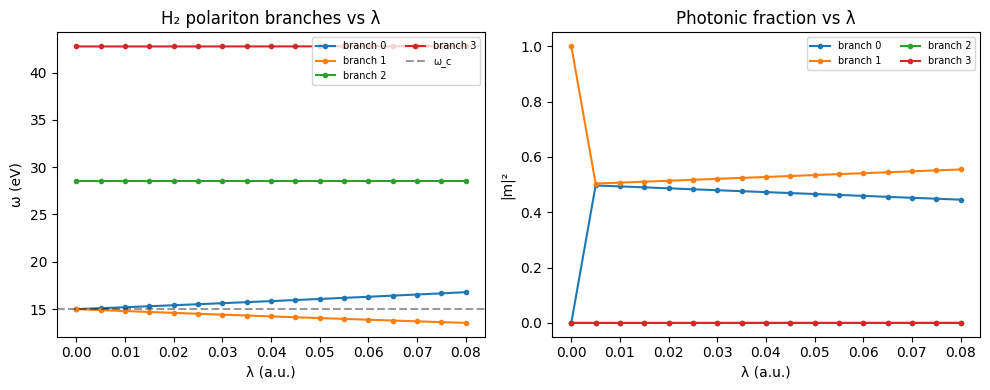

Approx. LP–UP gap at λ=0.080: 3.244 eV


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
for s in range(nstates_scan):
    ax.plot(lam_grid, omega_lam[:, s] * HA_TO_EV, "-o", ms=3, label=f"branch {s}")
ax.axhline(omega_c * HA_TO_EV, color="k", ls="--", alpha=0.4, label="ω_c")
ax.set_xlabel("λ (a.u.)")
ax.set_ylabel("ω (eV)")
ax.set_title("H₂ polariton branches vs λ")
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
for s in range(nstates_scan):
    ax.plot(lam_grid, phot_lam[:, s], "-o", ms=3, label=f"branch {s}")
ax.set_xlabel("λ (a.u.)")
ax.set_ylabel("|m|²")
ax.set_title("Photonic fraction vs λ")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

# Approximate Rabi gap near resonance: two states with largest |m|² mixing at max λ
imax = -1
mix = np.argsort(np.abs(phot_lam[imax] - 0.5))[:2]
rabi = abs(omega_lam[imax, mix[0]] - omega_lam[imax, mix[1]]) * HA_TO_EV
print(f"Approx. LP–UP gap at λ={lam_grid[imax]:.3f}: {rabi:.3f} eV")

---
## 4. PES scan — H₂ bond stretch with QED

For each bond length `R`:

1. SCF + `GTOKernel.setup()` (electronic `K` rebuilt — this is the costly step)
2. Fix cavity `ω_c` to the bright root at equilibrium (or retune — see flag below)
3. `solve_qed_tda` → collect + `track_states` / `scan_qed_tda`

Also plot the bare electronic TDA surface for comparison.

In [14]:
# --- scan controls (keep small for a quick notebook) ---
R_grid = np.linspace(0.60, 1.20, 13)  # Angstrom
basis = "6-31g"
xc = "pbe"
lam_pes = 0.05
polarization_pes = (0.0, 0.0, 1.0)
nstates_pes = 4  # ≤ n_trans+1; H₂/6-31g → 4
retune_cavity = False  # True → ω_c(R) = brightest bare root at each R

# Equilibrium cavity from R=0.74 Å (reuse earlier omega_c if available)
R_eq = 0.74
mf_eq = make_mf(f"H 0 0 0; H 0 0 {R_eq}", basis=basis, xc=xc)
k_eq, _ = make_gto_kernel(mf_eq, use_df=False, n_states=nstates_pes)
w_eq, _, f_eq = bare_tda_spectrum(k_eq)
omega_c_eq = float(w_eq[int(np.argmax(np.clip(f_eq, 0, None)))])
nstates_pes = min(nstates_pes, k_eq.n_trans + 1)
print(f"Fixed cavity ω_c = {omega_c_eq:.6f} Ha ({omega_c_eq*HA_TO_EV:.3f} eV) "
      f"from R={R_eq} Å; nstates_pes={nstates_pes}")

  GTOKernel ready: n_occ=1, n_unocc=3, n_trans=3, K_cached=True (35.29s)
Fixed cavity ω_c = 0.551077 Ha (14.996 eV) from R=0.74 Å; nstates_pes=4


In [15]:
kernels = []
E_scf = []
w_bare_pes = []
omega_c_used = []

t_scan0 = time.time()
for i, R in enumerate(R_grid):
    print(f"[{i+1}/{len(R_grid)}] R = {R:.3f} Å")
    mf = make_mf(f"H 0 0 0; H 0 0 {R}", basis=basis, xc=xc)
    E_scf.append(mf.e_tot)
    k, _ = make_gto_kernel(mf, use_df=False, n_states=nstates_pes)
    kernels.append(k)

    wb, _, fb = bare_tda_spectrum(k)
    w_bare_pes.append(wb[:nstates_pes])
    if retune_cavity:
        omega_c_used.append(float(wb[int(np.argmax(np.clip(fb, 0, None)))]))
    else:
        omega_c_used.append(omega_c_eq)

print(f"SCF+K for all geometries: {time.time()-t_scan0:.1f}s")
w_bare_pes = np.array(w_bare_pes)  # (nR, nstates)
E_scf = np.asarray(E_scf)

[1/13] R = 0.600 Å
  GTOKernel ready: n_occ=1, n_unocc=3, n_trans=3, K_cached=True (22.40s)
[2/13] R = 0.650 Å
  GTOKernel ready: n_occ=1, n_unocc=3, n_trans=3, K_cached=True (37.70s)
[3/13] R = 0.700 Å
  GTOKernel ready: n_occ=1, n_unocc=3, n_trans=3, K_cached=True (25.50s)
[4/13] R = 0.750 Å
  GTOKernel ready: n_occ=1, n_unocc=3, n_trans=3, K_cached=True (34.30s)
[5/13] R = 0.800 Å
  GTOKernel ready: n_occ=1, n_unocc=3, n_trans=3, K_cached=True (11.70s)
[6/13] R = 0.850 Å
  GTOKernel ready: n_occ=1, n_unocc=3, n_trans=3, K_cached=True (52.30s)
[7/13] R = 0.900 Å
  GTOKernel ready: n_occ=1, n_unocc=3, n_trans=3, K_cached=True (46.40s)
[8/13] R = 0.950 Å
  GTOKernel ready: n_occ=1, n_unocc=3, n_trans=3, K_cached=True (47.20s)
[9/13] R = 1.000 Å
  GTOKernel ready: n_occ=1, n_unocc=3, n_trans=3, K_cached=True (36.60s)
[10/13] R = 1.050 Å
  GTOKernel ready: n_occ=1, n_unocc=3, n_trans=3, K_cached=True (39.10s)
[11/13] R = 1.100 Å
  GTOKernel ready: n_occ=1, n_unocc=3, n_trans=3, K_cached=

In [20]:
# QED at each geometry (kernel already cached)
qed_results = []
for k, oc in zip(kernels, omega_c_used):
    qed_results.append(
        solve_qed_tda(
            k,
            options=QEDOptions(
                lam_scalar=lam_pes,
                polarization=polarization_pes,
                omega_c=oc,
                nstates=nstates_pes,
            ),
        )
    )

omega_qed, phot_qed = qed.track_states(qed_results)

# Also exercise scan_qed_tda API (same kernels, single ω_c)
out_api = scan_qed_tda(
    kernels,
    lam_vec=np.asarray(polarization_pes, float) * lam_pes,
    omega_c=omega_c_eq,
    nstates=nstates_pes,
    track=True,
)
assert out_api["omega_tracked"].shape == (len(R_grid), nstates_pes)
print("✓ scan_qed_tda API ok")

✓ scan_qed_tda API ok


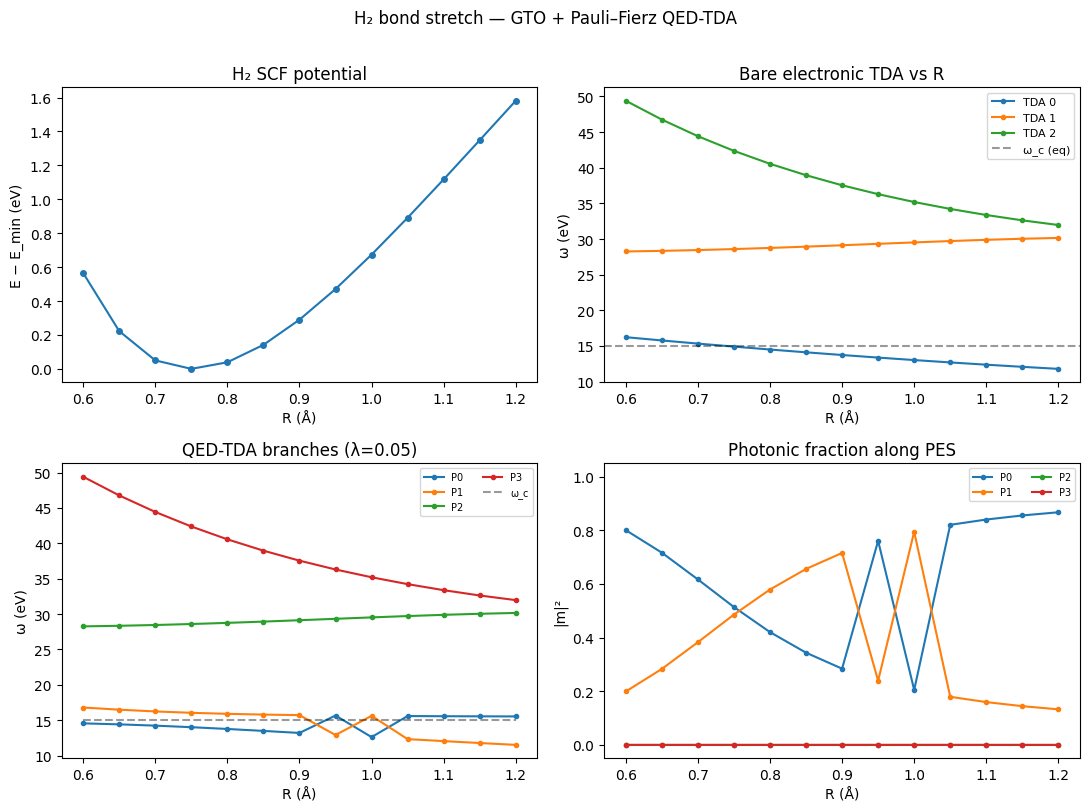

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# (0,0) SCF energy
ax = axes[0, 0]
ax.plot(R_grid, (E_scf - E_scf.min()) * HA_TO_EV, "-o", ms=4, color="C0")
ax.set_xlabel("R (Å)")
ax.set_ylabel("E − E_min (eV)")
ax.set_title("H₂ SCF potential")

# (0,1) bare electronic excitations (vertical)
ax = axes[0, 1]
for s in range(min(3, w_bare_pes.shape[1])):
    ax.plot(R_grid, w_bare_pes[:, s] * HA_TO_EV, "-o", ms=3, label=f"TDA {s}")
ax.axhline(omega_c_eq * HA_TO_EV, color="k", ls="--", alpha=0.4, label="ω_c (eq)")
ax.set_xlabel("R (Å)")
ax.set_ylabel("ω (eV)")
ax.set_title("Bare electronic TDA vs R")
ax.legend(fontsize=8)

# (1,0) QED polariton branches
ax = axes[1, 0]
for s in range(nstates_pes):
    ax.plot(R_grid, omega_qed[:, s] * HA_TO_EV, "-o", ms=3, label=f"P{s}")
ax.plot(R_grid, np.asarray(omega_c_used) * HA_TO_EV, "k--", alpha=0.4, label="ω_c")
ax.set_xlabel("R (Å)")
ax.set_ylabel("ω (eV)")
ax.set_title(f"QED-TDA branches (λ={lam_pes})")
ax.legend(fontsize=7, ncol=2)

# (1,1) photonic fraction along PES
ax = axes[1, 1]
for s in range(nstates_pes):
    ax.plot(R_grid, phot_qed[:, s], "-o", ms=3, label=f"P{s}")
ax.set_xlabel("R (Å)")
ax.set_ylabel("|m|²")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Photonic fraction along PES")
ax.legend(fontsize=7, ncol=2)

fig.suptitle("H₂ bond stretch — GTO + Pauli–Fierz QED-TDA", y=1.01)
fig.tight_layout()
plt.show()

### Optional: total polaritonic PES

Vertical excitation energies relative to the SCF ground state at each `R`
(useful when comparing avoided crossings on an absolute energy scale).

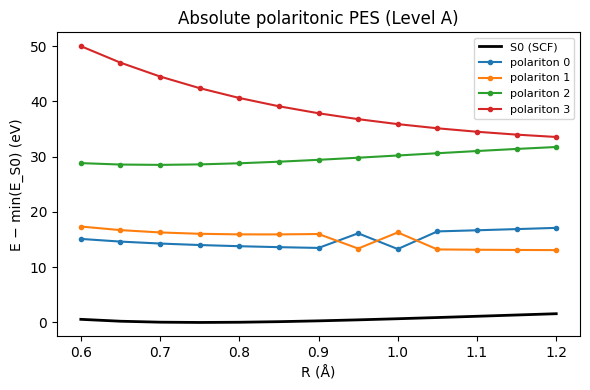

In [18]:
E_gs = E_scf  # Ha
E_pol = E_gs[:, None] + omega_qed  # (nR, nstates)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(R_grid, (E_gs - E_gs.min()) * HA_TO_EV, "k-", lw=2, label="S0 (SCF)")
for s in range(nstates_pes):
    ax.plot(
        R_grid,
        (E_pol[:, s] - E_gs.min()) * HA_TO_EV,
        "-o",
        ms=3,
        label=f"polariton {s}",
    )
ax.set_xlabel("R (Å)")
ax.set_ylabel("E − min(E_S0) (eV)")
ax.set_title("Absolute polaritonic PES (Level A)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

---
## 5. Quick diagnostics / gotchas

| Check | What to look for |
|-------|------------------|
| GTO vs PySCF | `Δω ≲ 1e-5` Ha |
| `λ → 0` | electronic roots = bare TDA; one root at `ω_c` with `|m|²→1` |
| Origin shift | `max|Δω| < 1e-8` with coherent-state on |
| DSE | spectrum changes when `include_dse=False` (diagnostic only) |
| PES tracking | branches continuous; `|m|²` swaps at resonance |

**Not the same as** `polariton_handler.py` (phenomenological `g0` Tavis–Cummings). Agree only in the weak-coupling / DSE-negligible limit.

Convention factors live in `casidapy/qed.py` (`SQRT2`, `DSE_DIRECT_FACTOR`) — adjust there if matching a published QED-TDA number requires a different closed-shell placement.

In [ ]:
# Dump a small summary table at equilibrium-like geometry (nearest R to 0.74)
i_eq = int(np.argmin(np.abs(R_grid - 0.74)))
r = qed_results[i_eq]
print(f"R = {R_grid[i_eq]:.3f} Å, λ = {lam_pes}, ω_c = {omega_c_used[i_eq]*HA_TO_EV:.3f} eV\n")
print(f"{'n':>3}  {'ω/eV':>10}  {'f':>10}  {'|m|²':>10}")
for n in range(r.omega.size):
    print(f"{n:3d}  {r.omega[n]*HA_TO_EV:10.4f}  {r.f[n]:10.4f}  {r.photon_frac[n]:10.4f}")